In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import joblib
import numpy as np
from utils.helper_survival_graphs import *

## KM stratified by LIPI score
run this section to reproduce **figure 3** KM graphs 

In [3]:
complete_data = pd.read_csv('data/rwd.csv')
train_set = pd.read_csv('mlef_pipeline/results/OS/C23/RWD/train_set.csv')
test_set = pd.read_csv('mlef_pipeline/results/OS/C23/RWD/test_set.csv')
model = joblib.load('mlef_pipeline/results/OS/C23/RWD/model_COX.pkl')

In [4]:
test_set = pd.merge(
    test_set,
    complete_data[['Subject', 'LIPI']],
    on='Subject',
    how='left'
)

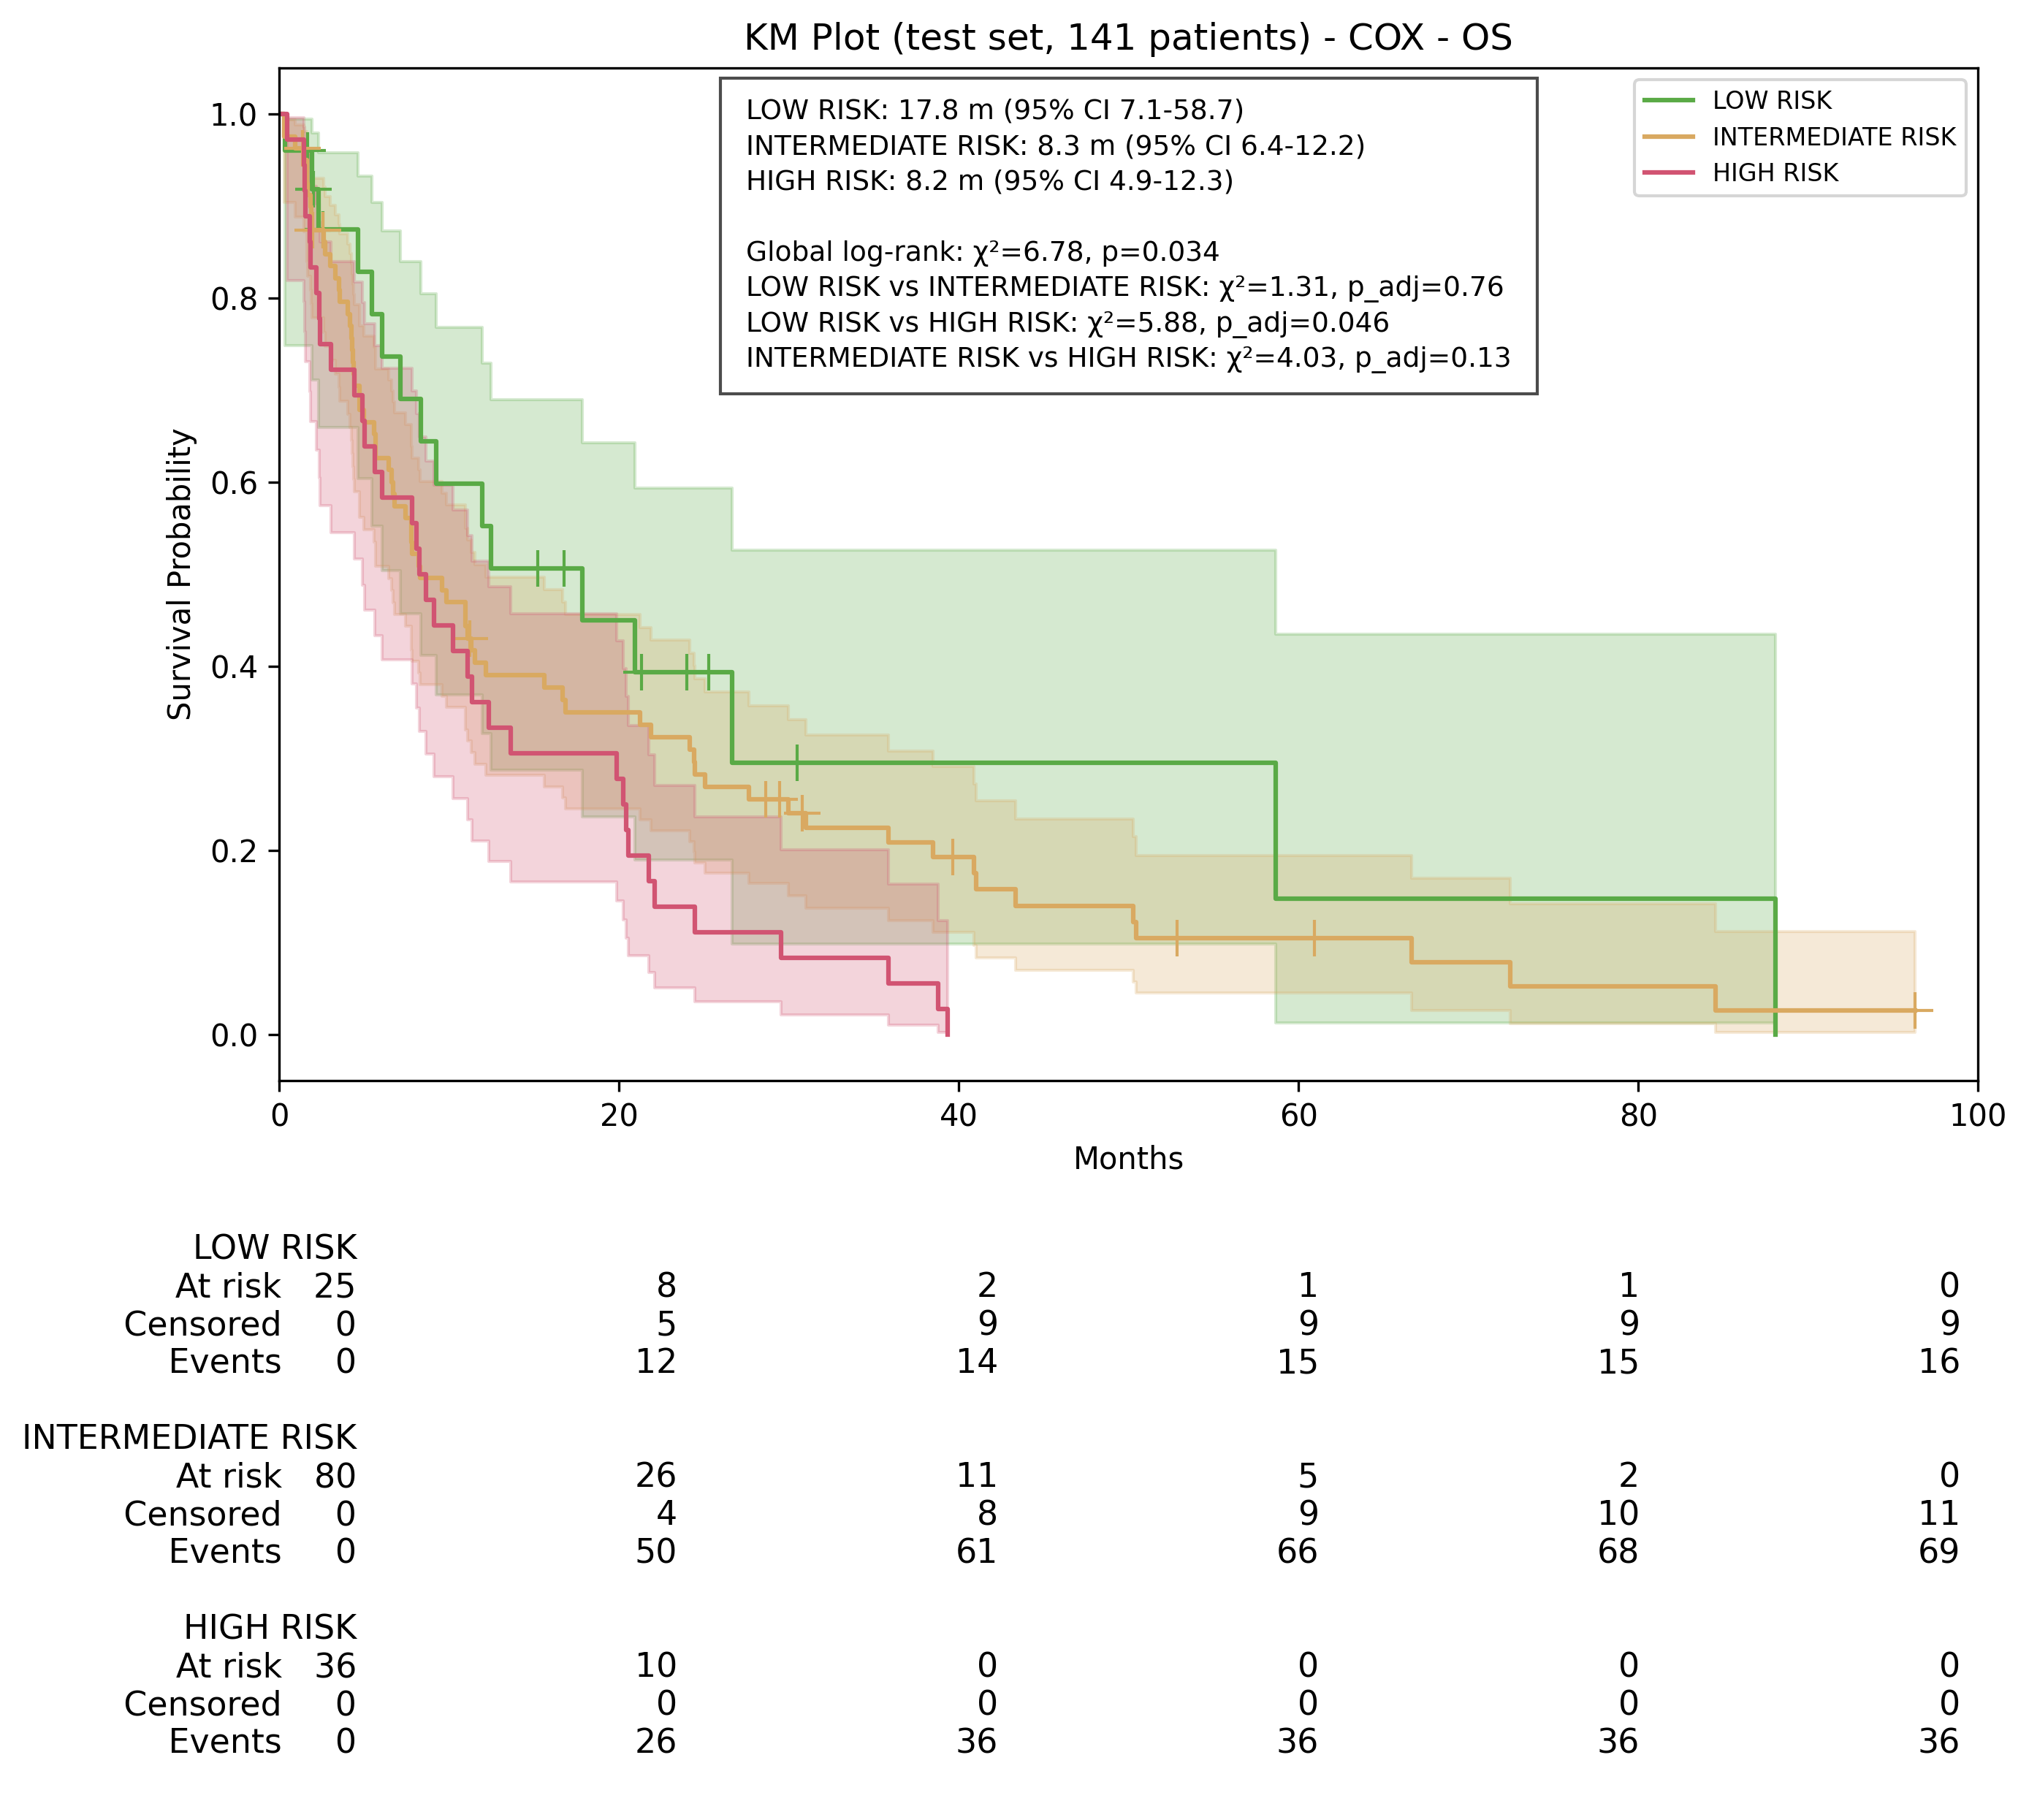

In [5]:
# Stratified by LIPI [Fig. e(i)]

good = test_set[test_set['LIPI'] == 0]
inter = test_set[test_set['LIPI'] == 1]
bad = test_set[test_set['LIPI'] == 2]

# Plot the combined Kaplan-Meier curve for OS
plot, df = plot_km_combined(
    datasets={
        'LOW RISK': good,
        'INTERMEDIATE RISK': inter,
        'HIGH RISK': bad,
    }, 
    stats=True
)

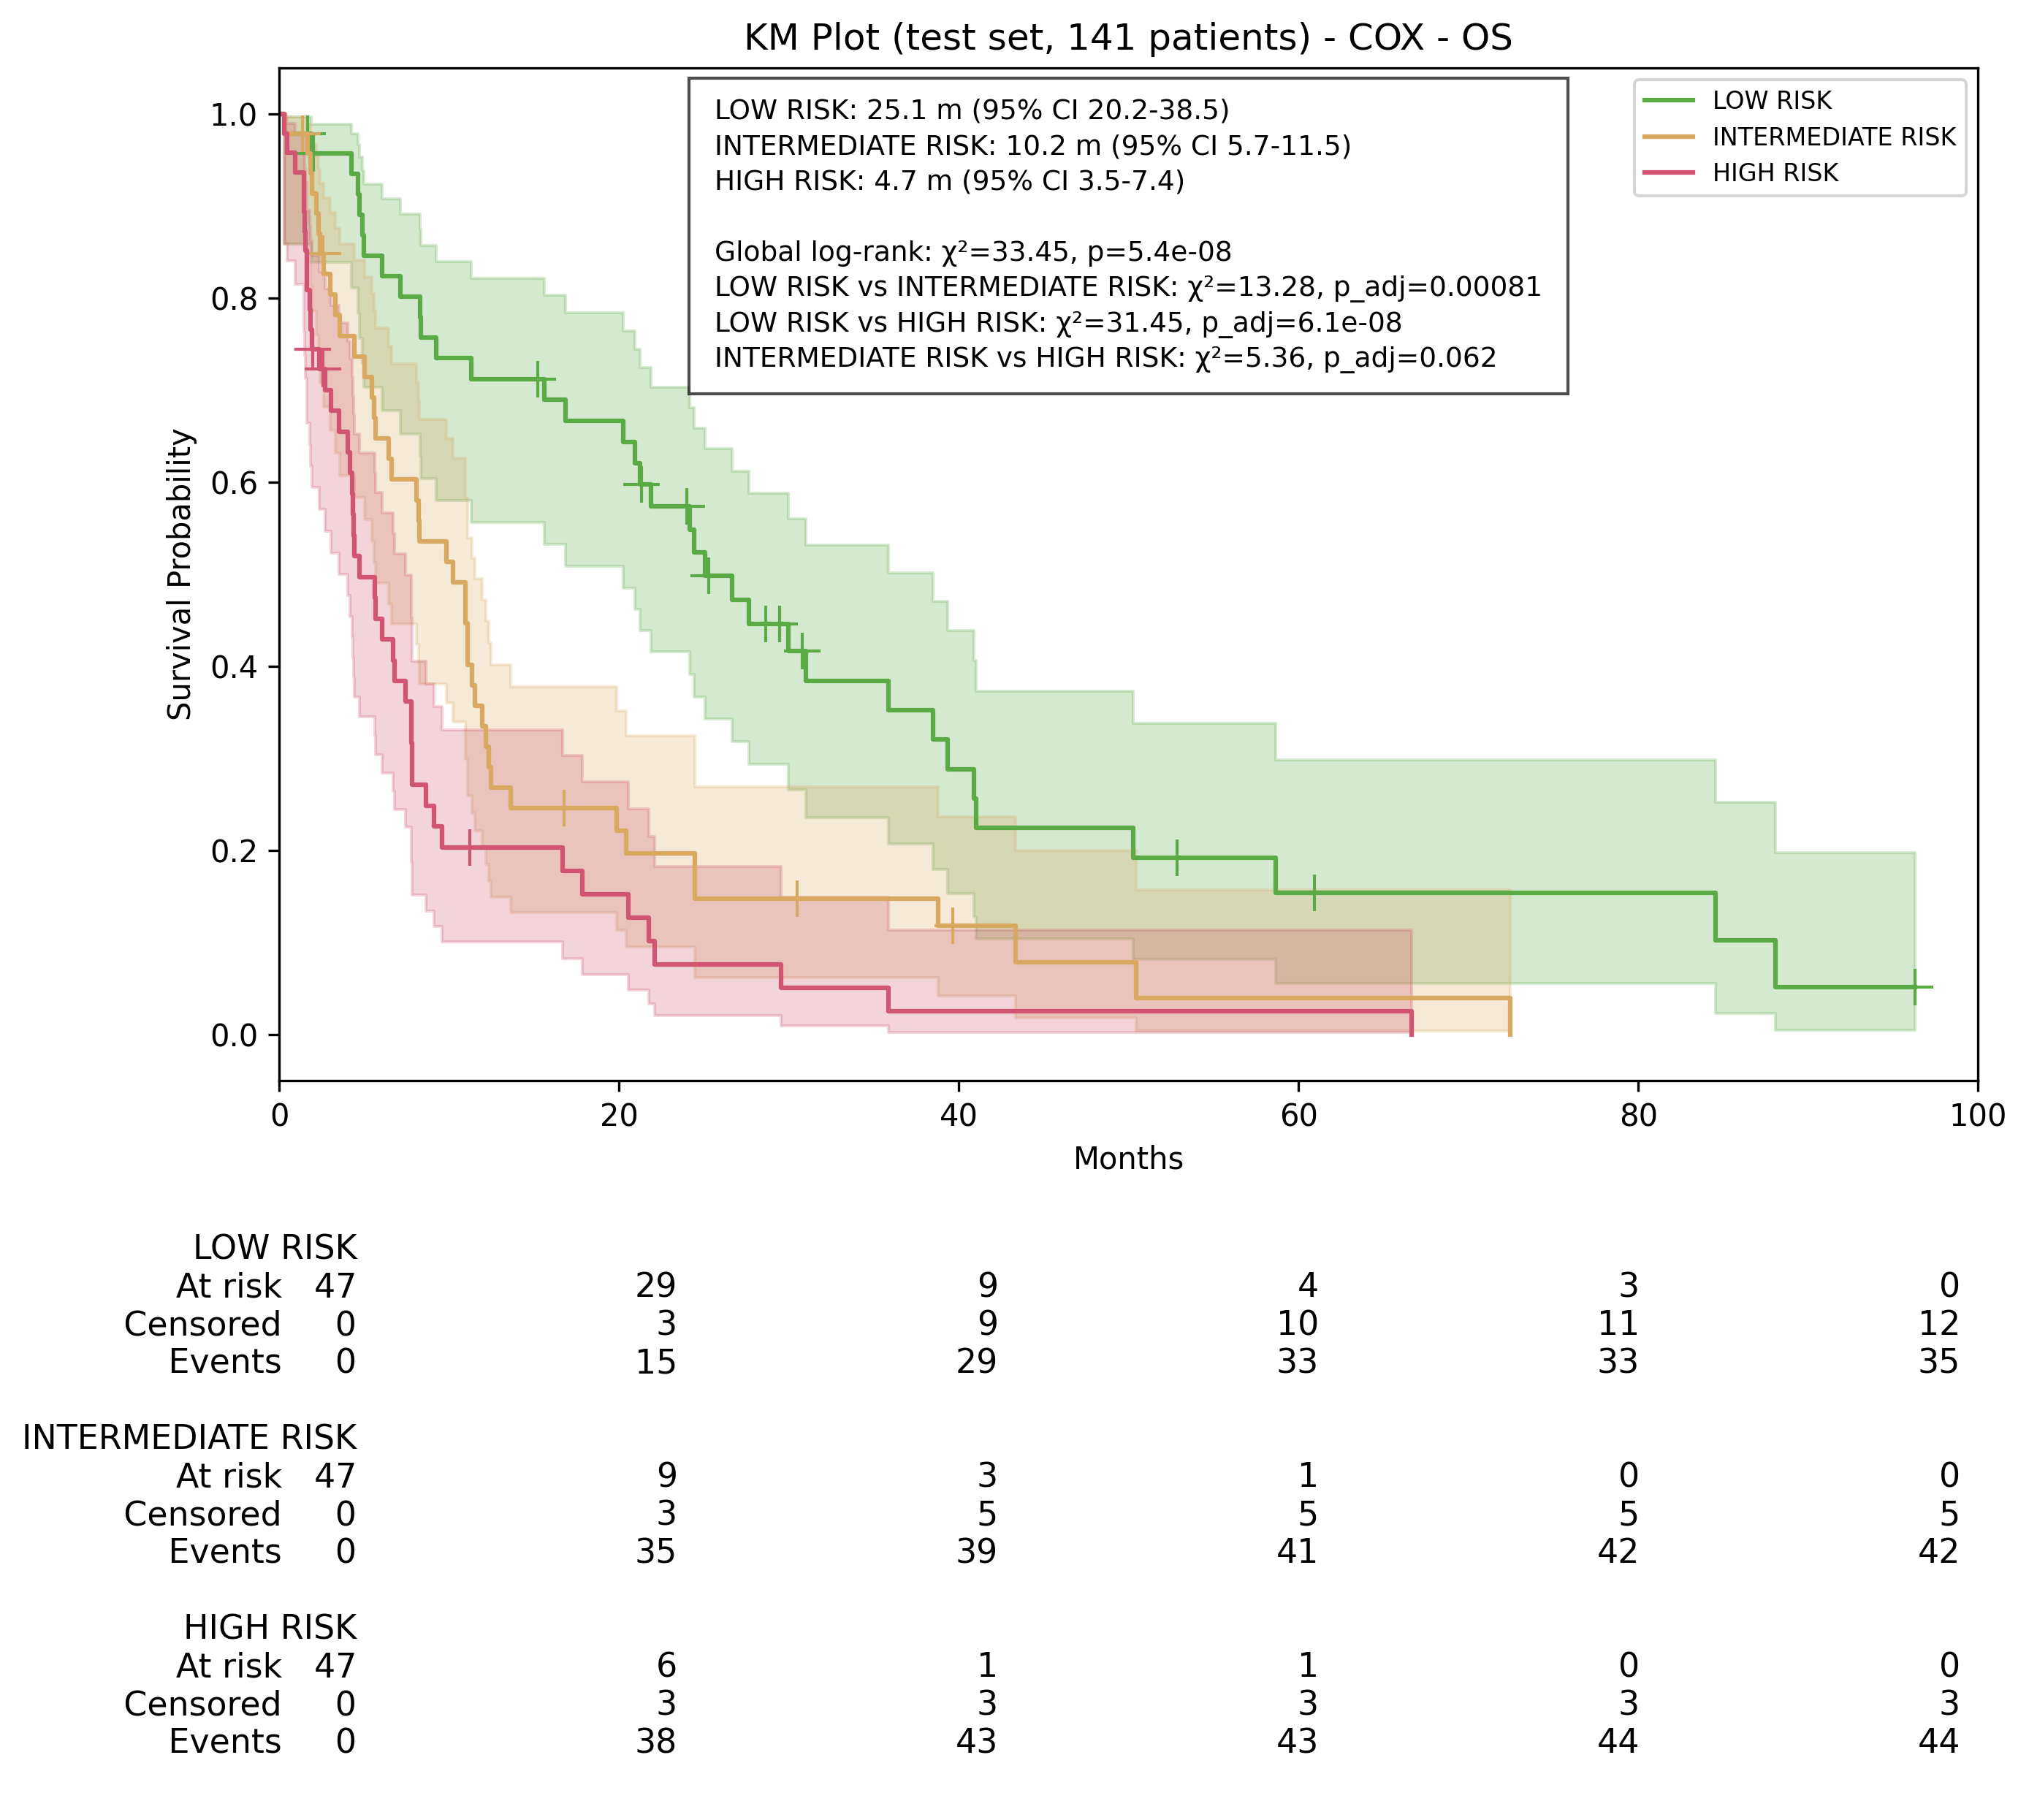

In [6]:
# Stratified by lipi [Fig. e(ii)]

lipi_df = test_set[test_set['LIPI'].notna()].reset_index(drop=True)
risk_scores = model.predict_partial_hazard(lipi_df).reset_index(drop=True)
tertiles = np.percentile(risk_scores, [33.33, 66.67])
lipi_df['risk_group'] = pd.cut(
    risk_scores,
    bins=[-np.inf, tertiles[0], tertiles[1], np.inf],
    labels=['Low risk', 'Intermediate risk', 'High risk'],
    include_lowest=True
)
low_risk = lipi_df[lipi_df['risk_group'] == 'Low risk']
intermediate_risk = lipi_df[lipi_df['risk_group'] == 'Intermediate risk']
high_risk = lipi_df[lipi_df['risk_group'] == 'High risk']

# Plot the combined Kaplan-Meier curve for OS
plot, df = plot_km_combined(
    datasets={
        'LOW RISK': low_risk, 
        'INTERMEDIATE RISK': intermediate_risk,
        'HIGH RISK': high_risk
    }, 
    stats=True
)

## Plot C-INDEX results

In [11]:
plot_cindex_results(
    architecture="DLIF",
    outcome="OS",
    analyses=["C23"],
    modality_order=[
        "RWD",
        "RWD_DP",
        "RWD_FMRAD",
        "RWD_PYRAD",
        "RWD_DP_FMRAD",
        "RWD_DP_PYRAD"
    ],
    exclude_modalities=("DP", "FMRAD", "PYRAD"),
    title_prefix=None,
    min_bubble=30,
    max_bubble=250,
    show=True,
    save_dir=None
)

TypeError: plot_cindex_results.<locals>._pair_paths_dlif() takes 2 positional arguments but 3 were given

## XAI analysis

PermutationExplainer explainer: 274it [00:37,  6.61it/s]                         


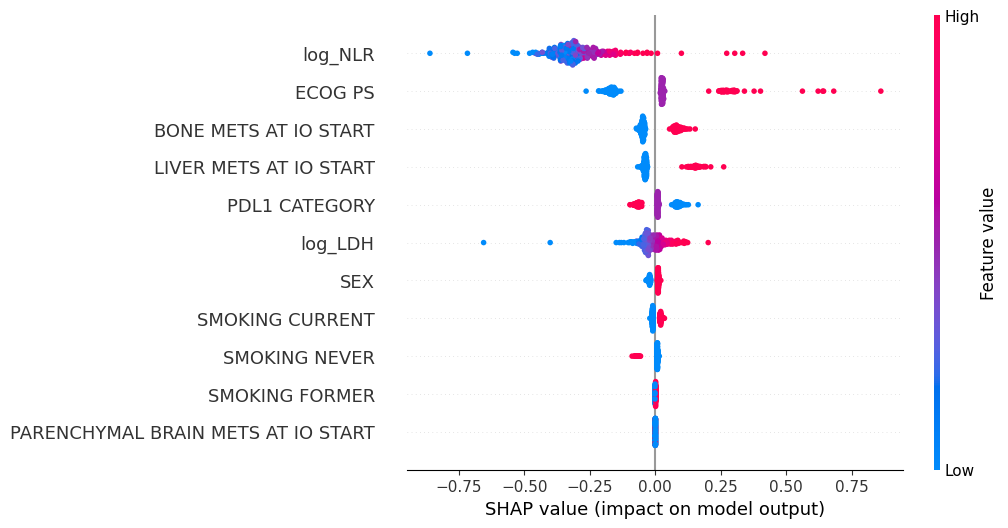

In [ ]:
features = train_set.drop(columns=['Subject', 'TIME', 'EVENT', 'FOLD']).columns

plt = shap_beeswarm(
    model=model,
    X_train=train_set[features],
    X_test=test_set[features],
    mapping={}
)

# Survival Fairness Analysis
**Expected directory structure:**
- Model: `mlef_pipeline/results/OS/C23/RWD/model.pkl` (trained Cox model)
- Test predictions: `MLEF/OS/C23/RWD/prediction_test.csv` (columns: Subject, EVENT, TIME, risk_score)
- External validation: `MLEF/OS/C23/RWD/prediction_external.csv` (columns: Subject, EVENT, TIME, risk_score)
- Clinical data: `data/rwd.csv` (contains demographic info: SEX, race columns)

**Analysis includes:**
1. C-index by medical center (test set)
2. C-index by race (external validation)
3. C-index by sex (test and external validation)
4. Bootstrap confidence intervals and statistical comparisons

In [2]:
from utils.helper_survival import *

In [3]:
# Configuration
BASE_PATH = Path('mlef_pipeline/results/OS/C23/RWD')
CLINICAL_DATA_PATH = Path('data/rwd.csv')
SITES = ['INT', 'GHD', 'VHIO', 'SZMC', 'MH']
N_BOOT = 1000
ALPHA = 0.05
SEED = 42

In [4]:
# Load data
# If prediction files are CSV use load_predictions, otherwise read Excel directly.
# Using pd.read_excel here to avoid UnicodeDecodeError when files are .xlsx

test_predictions = pd.read_csv(BASE_PATH / 'prediction_TEST.csv')
external_predictions = pd.read_csv(BASE_PATH / 'prediction_EXVAL.csv')

clinical_data = load_clinical_data(CLINICAL_DATA_PATH)
test_predictions = pd.merge(test_predictions, clinical_data, on='Subject', how='left')[['Subject', 'CENTER','risk_score', 'TIME', 'EVENT']]
print(f"Test set: {len(test_predictions)} patients")
print(f"External validation: {len(external_predictions)} patients")
print(f"Clinical data: {len(clinical_data)} patients")

Test set: 273 patients
External validation: 251 patients
Clinical data: 2075 patients


In [5]:
# Analysis by medical center
site_per_group, site_pairwise, site_overall_cindex = analyze_fairness_by_site(
    test_predictions, 
    SITES, 
    n_boot=N_BOOT, 
    seed=SEED
)


C-INDEX BY MEDICAL CENTER (Test Set)

INT      (n=102): 0.69 ± 0.06

GHD      (n= 65): 0.61 ± 0.10

VHIO     (n= 30): 0.57 ± 0.16

SZMC     (n= 41): 0.67 ± 0.17

MH       (n= 35): 0.50 ± 0.26

Overall  (n=273): 0.66 ± 0.04

------------------------------------------------------------
Pairwise Comparisons (Holm-corrected):
------------------------------------------------------------
GHD vs MH      : diff=+0.110, p=0.4267, p_holm=1.0000 ns
GHD vs SZMC    : diff=-0.058, p=0.5611, p_holm=1.0000 ns
GHD vs VHIO    : diff=+0.033, p=0.7260, p_holm=1.0000 ns
INT vs GHD     : diff=+0.081, p=0.1523, p_holm=1.0000 ns
INT vs MH      : diff=+0.191, p=0.1512, p_holm=1.0000 ns
INT vs SZMC    : diff=+0.022, p=0.8085, p_holm=1.0000 ns
INT vs VHIO    : diff=+0.114, p=0.1893, p_holm=1.0000 ns
SZMC vs MH      : diff=+0.169, p=0.2920, p_holm=1.0000 ns
VHIO vs MH      : diff=+0.077, p=0.6130, p_holm=1.0000 ns
VHIO vs SZMC    : diff=-0.091, p=0.4518, p_holm=1.0000 ns


In [6]:
# Analysis by race
race_per_group, race_pairwise, race_overall_cindex = analyze_fairness_by_race(
    external_predictions,
    clinical_data,
    n_boot=N_BOOT,
    seed=SEED
)


C-INDEX BY RACE (External Validation)

WHITE                          (n=113): 0.63 ± 0.08

BLACK OR AFRICAN AMERICAN      (n=125): 0.68 ± 0.07

Overall (n=251): 0.65 ± 0.05

------------------------------------------------------------
Pairwise Comparisons (Holm-corrected):
------------------------------------------------------------
WHITE vs BLACK OR AFRICAN AMERICAN: diff=-0.049, p=0.3585, p_holm=0.3585 ns


In [7]:
# Analysis by sex (test set)
sex_test_per_group, sex_test_pairwise, sex_test_overall_cindex = analyze_fairness_by_sex(
    test_predictions,
    clinical_data,
    set_name='test',
    n_boot=N_BOOT,
    seed=SEED
)


C-INDEX BY SEX (TEST Set)

Female   (n= 99): 0.70 ± 0.07

Male     (n=174): 0.64 ± 0.05

Overall  (n=273): 0.66 ± 0.04

------------------------------------------------------------
Pairwise Comparisons (Holm-corrected):
------------------------------------------------------------
Female vs Male    : diff=+0.054, p=0.2195, p_holm=0.2195 ns


In [8]:
# Analysis by sex (external validation)
sex_ext_per_group, sex_ext_pairwise, sex_ext_overall_cindex = analyze_fairness_by_sex(
    external_predictions,
    clinical_data,
    set_name='external',
    n_boot=N_BOOT,
    seed=SEED
)


C-INDEX BY SEX (EXTERNAL Set)

Female   (n=148): 0.64 ± 0.07

Male     (n=103): 0.68 ± 0.08

Overall  (n=251): 0.65 ± 0.05

------------------------------------------------------------
Pairwise Comparisons (Holm-corrected):
------------------------------------------------------------
Female vs Male    : diff=-0.045, p=0.3944, p_holm=0.3944 ns


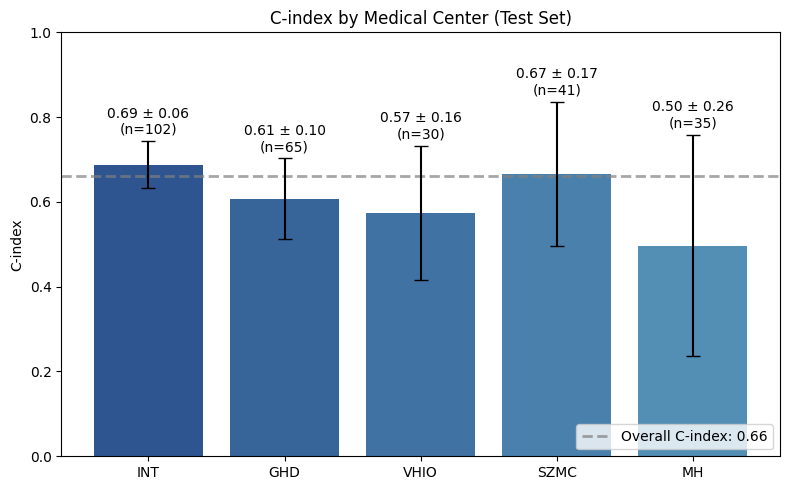

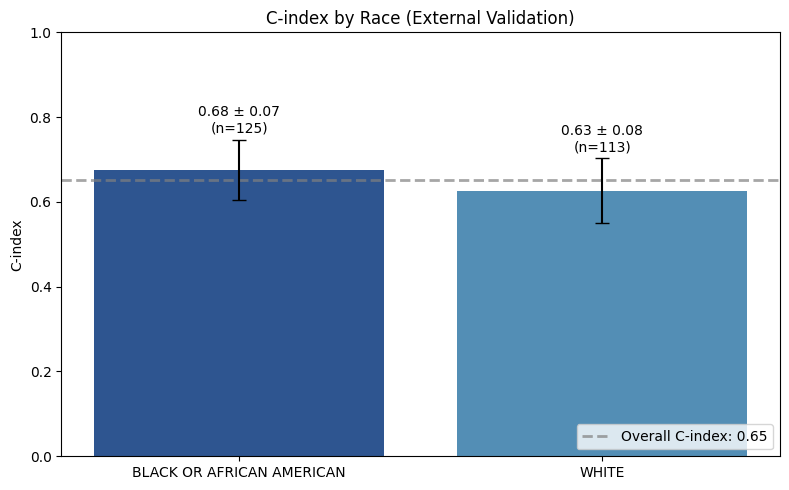

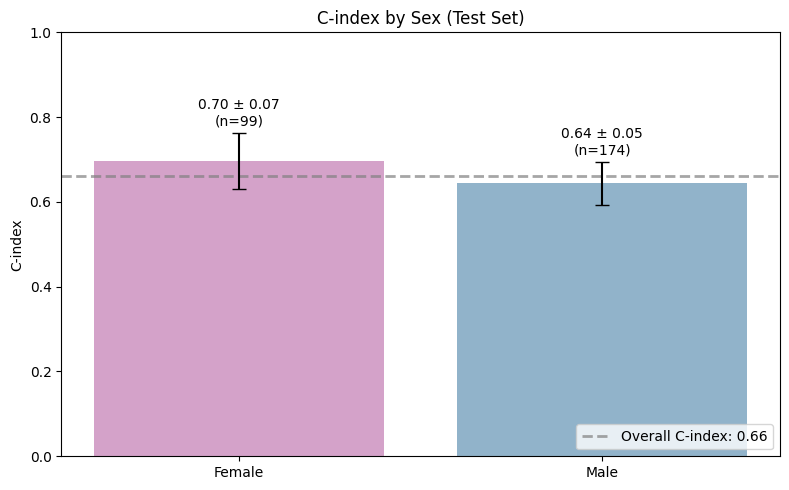

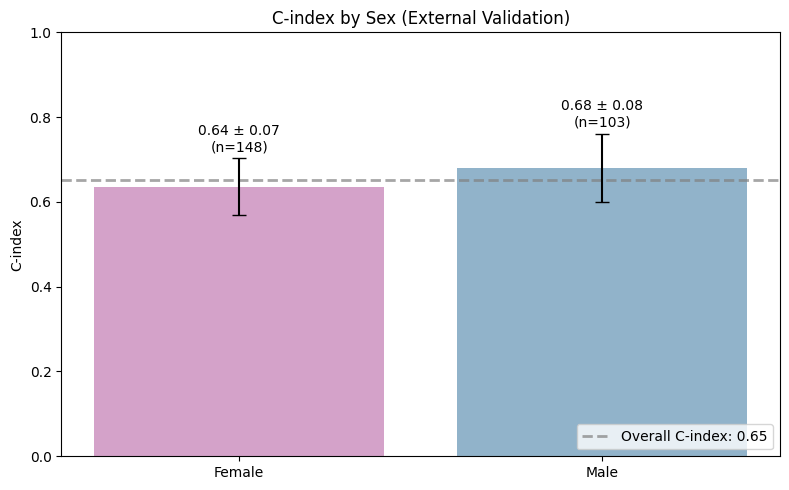

In [9]:
# Plot results
fig1 = plot_fairness_results(
    site_per_group, 
    'C-index by Medical Center (Test Set)', 
    group_order=['INT', 'GHD', 'VHIO', 'SZMC', 'MH'],
    overall_cindex=site_overall_cindex
)
if fig1:
    plt.show()

fig2 = plot_fairness_results(
    race_per_group, 
    'C-index by Race (External Validation)', 
    palette=["#1E52A0", '#4292C6'],
    overall_cindex=race_overall_cindex
)
if fig2:
    plt.show()

fig3 = plot_fairness_results(
    sex_test_per_group, 
    'C-index by Sex (Test Set)', 
    palette=["#dc9ace", '#88b5d3'],
    overall_cindex=sex_test_overall_cindex
)
if fig3:
    plt.show()

fig4 = plot_fairness_results(
    sex_ext_per_group, 
    'C-index by Sex (External Validation)', 
    palette=["#dc9ace", '#88b5d3'],
    overall_cindex=sex_ext_overall_cindex
)
if fig4:
    plt.show()